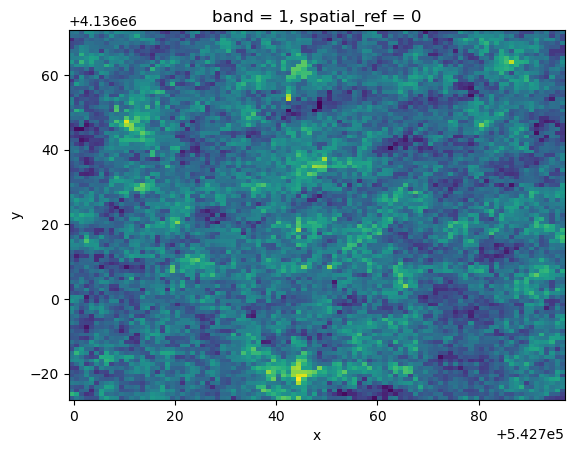

In [23]:
import numpy as np
import rioxarray
import rasterio
import pandas as pd
from pyproj import Proj, Transformer
wk_dir = "C:/Users/ngsim/Documents_SN/UCLA Grad School/SpecSchool/unmixing_files/"
coord_ref = 'EPSG:32617' # UTM 17
rds = rioxarray.open_rasterio(wk_dir + "2023_MLBS_hyp_raster_v3.tif", crs = coord_ref)
hyp_pxls = pd.read_csv(wk_dir + "2023_MLBS_hy_v3_fractions_cleaner_and_shade.csv"); 
fractions = rds[0]
fractions.attrs['long_name'] = 'fraction' # change long_name attribute so it's just one band
fractions.plot(add_colorbar=False)
#["understory_fraction", "dead_tree_fraction", "canopy_fraction", "shade_fraction"]
fraction = "shade_fraction" ## NOTE change this

In [24]:
fractions_p = fractions.rio.reproject(coord_ref).astype(np.float32)
fractions_p.values[:] = np.NaN # set all data to 0
# fractions_p.plot(add_colorbar=False)

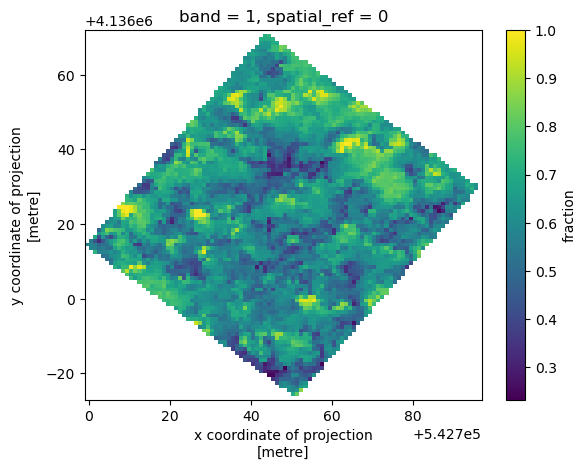

In [25]:
# Rewrite pixels to be desired value from csv file, matching longitude and latitude
p = Proj(coord_ref)
for i in range(len(hyp_pxls)):
    #print(i, end = ' ')
    long,lat = p(hyp_pxls['longitude'][i],hyp_pxls['latitude'][i]) # get lat long from pixel in grid format (I think these lat long are actually grid coordinates)
    fractions_p_sel = fractions_p.sel(x = long, y = lat, method = 'nearest') # find closest pixel in existing raster
    fractions_p.loc[dict(x = fractions_p_sel.x.values, y = fractions_p_sel.y.values)] = hyp_pxls[fraction][i] # rewrite value of pixel with value from spreadsheet
fractions_p.rio.to_raster(wk_dir + "2023_MLBS_" + fraction + "_cleaner_and_shade.tif")

fractions_p.plot()

10cm RGB pixel

<xarray.DataArray (y: 969, x: 2073)> Size: 8MB
[2008737 values with dtype=int32]
Coordinates:
    band         int32 4B 1
  * x            (x) float64 17kB 3.342e+05 3.342e+05 ... 3.344e+05 3.344e+05
  * y            (y) float64 8kB 3.603e+06 3.603e+06 ... 3.603e+06 3.603e+06
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        2
    STATISTICS_MEAN:           0.49679534520593
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         0.80372525438909
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0
    long_name:                 classification

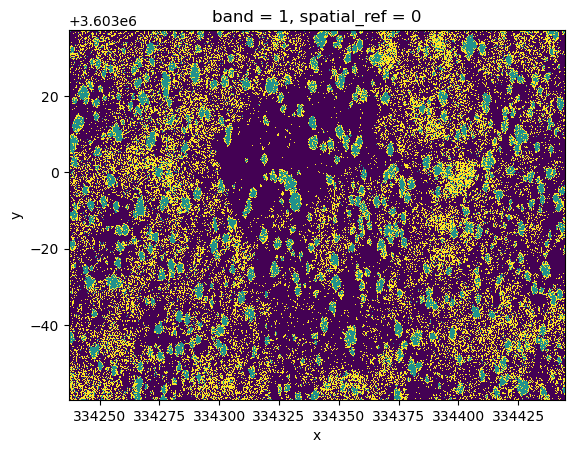

In [3]:
rds = rioxarray.open_rasterio("C:/Users/ngsim/Documents_SN/UCLA Grad School/Geog 214/NEON AOP Spectral Unmixing/soil_GV_NPV_classification_CART_20pts.tif", crs = 'EPSG:32113')
#rgb_pxls = pd.read_csv("C:/Users/ngsim/Documents_SN/UCLA Grad School/Geog 214/NEON AOP Spectral Unmixing/NEAT3_test_251126_classified_data_only.csv"); 
rgb_pxls = pd.read_csv("C:/Users/ngsim/Documents_SN/UCLA Grad School/Geog 214/NEON AOP Spectral Unmixing/NEAT3_test_251204_middle_sect_classified_csv.csv"); 
classification = rds[0]
classification.plot(add_colorbar=False)
classification

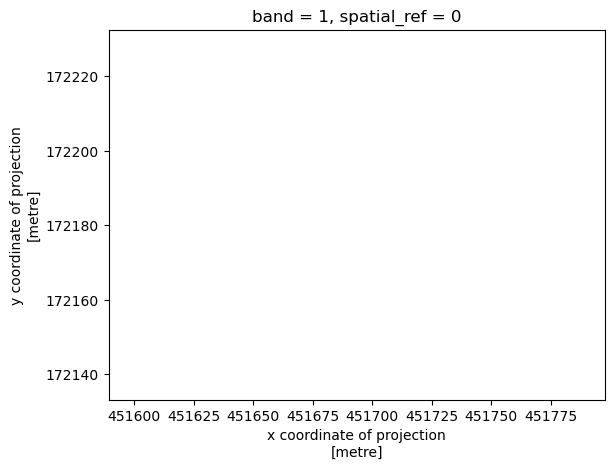

In [185]:
classification_p = classification.rio.reproject("EPSG:32113").astype(np.float32)
classification_p.values[:] = np.NaN # set all data to NaN
classification_p.plot(add_colorbar=False)

In [186]:
# Rewrite pixels to be desired value from csv file, matching longitude and latitude
p = Proj('EPSG:32113')
for i in range(len(rgb_pxls)):
    #print(i, end = ' ')
    long,lat = p(rgb_pxls['longitude'][i],rgb_pxls['latitude'][i]) # get lat long from pixel in grid format (I think these lat long are actually grid coordinates)
    classification_p_sel = classification_p.sel(x = long, y = lat, method = 'nearest') # find closest pixel in existing raster
    classification_p.loc[dict(x = classification_p_sel.x.values,y = classification_p_sel.y.values)] = rgb_pxls['classification'][i] # rewrite value of pixel with value from spreadsheet

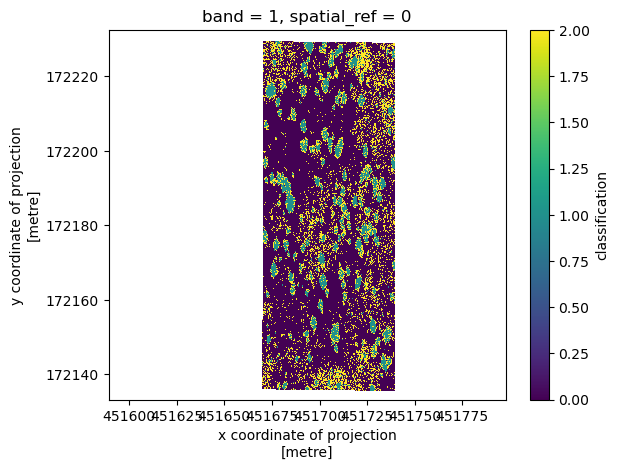

In [187]:
classification_p.plot()

In [182]:
classification_p.rio.to_raster("C:/Users/ngsim/Documents_SN/UCLA Grad School/Geog 214/NEON AOP Spectral Unmixing/classification_from_CSV_251203.tif")